Use SVM to bulid and train model using human cell record , and classify cells to whether the samples are mild state or evil state


In [3]:
#IMPORTING THE BASIC LIBRARIES 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv('cell_samples.csv')

In [6]:
df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [7]:
df.tail()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4
698,897471,4,8,8,5,4,5,10,4,1,4


In [9]:
df.shape

(699, 11)

In [10]:
df.count()

ID             699
Clump          699
UnifSize       699
UnifShape      699
MargAdh        699
SingEpiSize    699
BareNuc        699
BlandChrom     699
NormNucl       699
Mit            699
Class          699
dtype: int64

In [11]:
df.size

7689

In [17]:
# class 4 means malignant state
# class 2 means benign state
df['Class'].value_counts()

Class
2    458
4    241
Name: count, dtype: int64

In [18]:
df['Clump'].value_counts()

Clump
1     145
5     130
3     108
4      80
10     69
2      50
8      46
6      34
7      23
9      14
Name: count, dtype: int64

In [19]:
# malignant-->evil state
# benign-->mild state


In [21]:
#rows belongs to malignant and benign
benign=df[df['Class']==2][0:200]
malignant=df[df['Class']==4][0:200]

<Axes: xlabel='Clump', ylabel='UnifSize'>

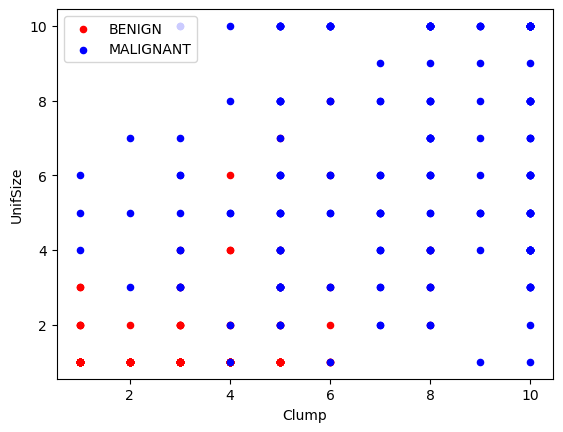

In [26]:
#SCATTERED PLOT
axes = benign.plot(kind='scatter', x='Clump' , y='UnifSize' , color='red',label='BENIGN')
malignant.plot(kind='scatter', x='Clump' , y='UnifSize' , color='blue',label='MALIGNANT' , ax=axes)

In [33]:
#checking and handling the datatypes

In [34]:
df.dtypes

ID             int64
Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc        int64
BlandChrom     int64
NormNucl       int64
Mit            int64
Class          int64
dtype: object

In [35]:
df=df[pd.to_numeric(df['BareNuc'],errors='coerce').notnull()]
df.dtypes

ID             int64
Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc        int64
BlandChrom     int64
NormNucl       int64
Mit            int64
Class          int64
dtype: object

In [36]:
df['BareNuc']= df['BareNuc'].astype('int')
df.dtypes

ID             int64
Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc        int64
BlandChrom     int64
NormNucl       int64
Mit            int64
Class          int64
dtype: object

In [38]:
#removing unwanted columns ---> features engineering
df.columns
features=df[['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize',
       'BareNuc', 'BlandChrom', 'NormNucl', 'Mit']]
#picked 9 columns out of 11

In [39]:
#INDEPENDENT VARIABLE
X=np.asarray(features)
#DEPENDENT VARIABLE
Y=np.asarray(df['Class'])

In [40]:
X[0:5]

array([[ 5,  1,  1,  1,  2,  1,  3,  1,  1],
       [ 5,  4,  4,  5,  7, 10,  3,  2,  1],
       [ 3,  1,  1,  1,  2,  2,  3,  1,  1],
       [ 6,  8,  8,  1,  3,  4,  3,  7,  1],
       [ 4,  1,  1,  3,  2,  1,  3,  1,  1]])

In [41]:
#testing and training of model by splitting the data
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X , Y , test_size=0.2,random_state=42)

In [47]:
X_train.shape

(546, 9)

In [48]:
Y_train.shape

(546,)

In [51]:
X_test.shape

(137, 9)

In [52]:
Y_test.shape

(137,)

In [56]:
#MODELLING (SVM WITH SKLEARN)
from sklearn import svm
#SVM classifiers --> SVC
#gamma is a kernel coefficients which will be equal to default value that is auto
#c is the penelty for the incorrectly placed datapoints
classifier = svm.SVC(kernel='linear',gamma='auto',C=2)


In [58]:
classifier.fit(X_train,Y_train)

SVC(C=2, gamma='auto', kernel='linear')

In [59]:
y_predict = classifier.predict(X_test)

In [60]:
from sklearn.metrics import classification_report
print(classification_report(Y_test , y_predict))

              precision    recall  f1-score   support

           2       0.95      0.99      0.97        79
           4       0.98      0.93      0.96        58

    accuracy                           0.96       137
   macro avg       0.97      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137

